# Función de Producción Cobb-Douglas — España v2
## Econometría | Mankiw Cap. 3 + Wooldridge Cap. 12
### Fuentes: Eurostat (PIB, Empleo) + INE (Stock neto de capital)

**Mejora respecto a v1:** Stock neto de capital real en lugar de FBCF como proxy.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
# Estilo institucional para todas las gráficas
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})


Librerías cargadas ✓


## Abstract

This paper estimates a Cobb-Douglas production function for the Spanish economy 
over the period 1995–2021 using national accounts data from Eurostat, EU KLEMS, 
and the BBVA-Ivie Foundation. We find constant returns to scale (α + β = 1.008), 
with capital elasticity α = 0.407 and labour elasticity β = 0.601, consistent 
with neoclassical theory (Mankiw, 2019). Serial correlation is detected and 
corrected following Wooldridge (2019, Ch. 12) using first differences, dummy 
variables for structural breaks, and HAC standard errors. Total Factor 
Productivity declined during the housing bubble (2000–2009) and partially 
recovered post-crisis, suggesting Spanish growth was extensive rather than 
intensive during the boom period.

**Keywords:** Cobb-Douglas, Total Factor Productivity, Serial Correlation, 
Spanish Economy, HAC Standard Errors

**JEL Codes:** C22, E23, O47

In [226]:
df_ivie = pd.read_csv("/Users/eduardromero/Documents/edalytics_website/posts/mi-proyecto/data/DE_2026_BBDD_Stock_nacional-activosbasicos.csv",
sep = None,
engine = 'python')

print("Shape: ", df_ivie.shape)
print("\nColumnas: ", df_ivie.columns.tolist()[:10])
print("\nPrimeras filas: ")
print(df_ivie.head())

Shape:  (11280, 67)

Columnas:  ['\ufeffVARIABLE', 'UNIDAD', 'ACTIVO', 'RAMA', 'LUGAR', '1964', '1965', '1966', '1967', '1968']

Primeras filas: 
         ﻿VARIABLE  ...         2025
0  Inversión bruta  ...  287053623,1
1  Inversión bruta  ...  5033164,636
2  Inversión bruta  ...  56849443,91
3  Inversión bruta  ...  15811965,42
4  Inversión bruta  ...  1284363,453

[5 rows x 67 columns]


In [227]:
df_ivie = pd.read_csv("/Users/eduardromero/Documents/edalytics_website/posts/mi-proyecto/data/DE_2026_BBDD_Stock_nacional-activosbasicos.csv",
sep = None, 
engine = "python",
encoding = "utf-8-sig") #elimina el BOM

print("Variables disponibles: ")
print(df_ivie["VARIABLE"].unique())

print("\nActivos disponibles: ")
print(df_ivie['ACTIVO'].unique())

print("\nRamas disponibles (muestra): ")
print(df_ivie['RAMA'].unique()[:10])

print("\nLugares disponibles (muestra)")
print(df_ivie['LUGAR'].unique())

Variables disponibles: 
['Inversión bruta' 'Stock de capital neto riqueza'
 'Stock de capital productivo']

Activos disponibles: 
['0. Total' '1. Activos materiales' '1.1. Viviendas'
 '1.2. Otras construcciones' '1.3. Equipo de transporte'
 '1.3.1. Vehículos de motor' '1.3.2. Otro material de transporte'
 '1.4. Maquinaria, equipo y otros activos' '1.4.1. Productos metálicos'
 '1.4.2. Maquinaria y equipo mecánico' '1.4.3. Equipo de oficina y hardware'
 '1.4.4. Otra maquinaria y equipo' '1.4.4.1. Comunicaciones'
 '1.4.4.2. Otra maquinaria y equipo n.c.o.p.' '1.5. Activos cultivados'
 '2. Activos inmateriales' '2.1. Software' '2.2. Otros activos inmateriales'
 '2.2.1. I+D' '2.2.2. Resto de activos inmateriales' 'Total sin viviendas'
 'Activos materiales sin viviendas'
 'Otras agrupaciones de activos: Equipo TIC (1.4.3 y 1.4.4.1)'
 'Otras agrupaciones de activos: Maquinaria, equipo y otros activos no TIC (1.3, 1.4 (excepto 1.4.3 y 1.4.4.1) y 1.5)']

Ramas disponibles (muestra): 
['0. Total

In [228]:
#Filtrar stock neto de capital para toda espana
k_ivie = df_ivie[
    (df_ivie['VARIABLE'] == 'Stock de capital neto riqueza') &
    (df_ivie['ACTIVO'] == '0. Total') &
    (df_ivie['RAMA'] == '0. Total')
].copy()

print("Filas encontradas: ", len(k_ivie))


Filas encontradas:  4


In [229]:
k_ivie['UNIDAD'].unique()

array(['Miles de euros constantes base 2020', 'Miles de euros corrientes',
       'Tasa de variación anual real (Tornqvist). Porcentaje',
       'Índice de volumen 2020 = 100'], dtype=object)

In [230]:
k_ivie_2 = df_ivie[
    (df_ivie['VARIABLE'] == 'Stock de capital neto riqueza') &
    (df_ivie['ACTIVO'] == '0. Total') &
    (df_ivie['RAMA'] == '0. Total') &
    (df_ivie['UNIDAD'] == 'Miles de euros constantes base 2020')
].copy()

In [231]:

print(k_ivie_2)

                           VARIABLE  ...        2025
4512  Stock de capital neto riqueza  ...  4731246312

[1 rows x 67 columns]


In [232]:
k_ivie_2

,VARIABLE,UNIDAD,ACTIVO,RAMA,LUGAR,1964,1965,1966,1967,1968,1969,1970,1971,1972,1973,1974,1975,1976,1977,1978,1979,1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
4512,Stock de capital neto riqueza,Miles de euros constantes base 2020,0. Total,0. Total,España,"590413828,8","625023544,2","664672469,1","709617398,3","763015413,6","819078721,8","873239423,3",923330360,"982542351,1",1051034012,1122657354,1186079857,1246513257,1303930073,1356566076,1403355155,1448648424,1491047197,1533010754,1571990125,1605006637,1641831002,1685974600,1739916207,1805340978,1882528375,1965291360,2046598641,2118906671,2176104167,2234151360,2300541925,2367655604,2439775273,2525004124,2622690455,2729495346,2839281805,2952652054,3075570314,3203657387,3343238781,3495527249,3651397472,3786778015,3868261206,3936155684,3985639710,4018733369,4044171664,4076704368,4117368242,4158932913,4211442273,4274381052,4345004650,4390778290,4441768430,4500984534,4571390587,4646721771,4731246312


In [233]:
k_ivie_clean = pd.melt(k_ivie_2, id_vars = ['VARIABLE','UNIDAD', 'ACTIVO','RAMA','LUGAR'])[['variable','value']]

In [234]:
k_ivie_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   variable  62 non-null     object
 1   value     62 non-null     object
dtypes: object(2)
memory usage: 1.1+ KB


In [235]:
k_vie_clean_2 = k_ivie_clean['value'].replace(to_replace = r'\,',value ='.', regex = True )

In [236]:
k_ivie_clean['value'] = k_vie_clean_2

In [237]:
k_ivie_clean.columns=['year','K']

In [238]:
k_ivie_clean

,year,K
0,1964,590413828.8
1,1965,625023544.2
2,1966,664672469.1
3,1967,709617398.3
4,1968,763015413.6
...,...,...
57,2021,4441768430
58,2022,4500984534
59,2023,4571390587
60,2024,4646721771


In [239]:
df_ivie.VARIABLE.unique()

array(['Inversión bruta', 'Stock de capital neto riqueza',
       'Stock de capital productivo'], dtype=object)

# Empleo

In [240]:
xl = pd.ExcelFile('data/ES_national accounts.xlsx')
print(xl.sheet_names)

['Legend', 'VA_CP', 'GO_CP', 'II_CP', 'VA_PYP', 'GO_PYP', 'II_PYP', 'COMP', 'EMP', 'EMPE', 'H_EMP', 'H_EMPE', 'VA_PI', 'GO_PI', 'II_PI', 'VA_Q', 'GO_Q', 'II_Q']


In [241]:
emp = pd.read_excel(open("/Users/eduardromero/Documents/edalytics_website/posts/mi-proyecto/data/ES_national accounts.xlsx",'rb'),sheet_name = 'H_EMP')

In [242]:
emp

,var,nace_r2_code,geo_code,nace_r2_name,geo_name,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,H_EMP,A,ES,"Agriculture, forestry and fishing",Spain,2060690,2091676,2067128,2100776,2034723,1992409,2007718,1982136,1942432,1888725,1831585,1732928,1689664,1626880,1555916,1551831,1532619,1494593,1468367,1468763,1467630,1527666,1562339,1542424,1506694,1461849,1515257
1,H_EMP,B,ES,Mining and quarrying,Spain,77094,75740,73349,69857,71855,69533,73494,76139,81521,86744,82925,80627,81653,77696,66141,60750,52919,43510,36974,37144,35922,34150,32097,33892,33651,32279,34485
2,H_EMP,C,ES,Manufacturing,Spain,4106582,4297507,4542703,4762479,4974807,5154291,5147260,5085246,5062951,5013436,4936264,4814689,4682289,4641577,4031857,3890896,3737561,3430000,3254318,3218036,3308835,3363364,3536794,3593588,3670034,3346807,3452213
3,H_EMP,C10-C12,ES,Manufacture of food products; beverages and to...,Spain,714040,725883,739669,762473,780917,765899,757810,774258,793134,808725,814071,808124,797837,833035,786339,784651,776075,739773,716110,706305,715795,708613,747933,742195,807060,779229,774573
4,H_EMP,C13-C15,ES,"Manufacture of textiles, wearing apparel, leat...",Spain,557036,584131,619033,639019,646081,626577,605735,572068,549016,507774,471642,428426,383993,355905,300804,296511,296723,260190,252901,250317,262377,283190,278719,278287,274411,230972,220974
5,H_EMP,C16-C18,ES,"Manufacture of wood, paper, printing and repro...",Spain,369716,387582,408764,427333,438634,456003,453738,468601,469640,478285,464701,464919,442995,439278,376538,350056,317952,285661,258810,248984,256592,264424,272767,274191,276036,245131,273671
6,H_EMP,C19,ES,Manufacture of coke and refined petroleum prod...,Spain,15652,16269,16884,15564,14188,13895,13691,13390,13330,13204,13459,13392,13892,14648,13915,14116,15153,14037,13630,13551,12914,13460,13489,13763,13783,13959,13343
7,H_EMP,C20,ES,Manufacture of chemicals and chemical products,Spain,166694,169691,177761,186464,197590,212053,211484,204775,205427,201480,195282,189821,185872,183735,168873,169062,150508,146677,140092,139528,140315,147532,151349,155306,162004,156072,166184
8,H_EMP,C20-C21,ES,Chemicals; basic pharmaceutical products,Spain,224212,227641,237443,247388,260949,278785,278167,273001,275374,272556,265721,259626,255258,253129,236025,238447,218243,218592,210713,209805,215306,227346,242312,235337,245797,250261,262532
9,H_EMP,C21,ES,Manufacture of basic pharmaceutical products a...,Spain,57518,57950,59682,60924,63359,66732,66683,68226,69947,71076,70439,69805,69386,69394,67152,69385,67735,71915,70621,70277,74991,79814,90963,80031,83793,94189,96348


In [243]:
emp_filt = emp[(emp['nace_r2_code']=='TOT')]

In [244]:
emp_filt

,var,nace_r2_code,geo_code,nace_r2_name,geo_name,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
55,H_EMP,TOT,ES,Total - all NACE activities,Spain,24056454,24467619,25423001,26676910,27985967,29326206,30469190,31248173,32072817,32965055,34029988,35211548,36095061,36338856,34168083,33392886,32685722,31111891,30228797,30543000,31458248,32261468,32952218,33765616,34348534,30576947,32787923


In [245]:
emp_tot = pd.melt(emp_filt,id_vars = ['var','nace_r2_code', 'geo_code', 'nace_r2_name','geo_name'])[['variable', 'value']]

In [246]:
emp_tot.columns = ['year','L']

In [247]:
emp_tot

,year,L
0,1995,24056454
1,1996,24467619
2,1997,25423001
3,1998,26676910
4,1999,27985967
5,2000,29326206
6,2001,30469190
7,2002,31248173
8,2003,32072817
9,2004,32965055


In [248]:
k_ivie_clean = pd.melt(k_ivie_2, id_vars = ['VARIABLE','UNIDAD', 'ACTIVO','RAMA','LUGAR'])[['variable','value']]

In [249]:
import eurostat

pib_raw = eurostat.get_data_df('nama_10_gdp')

pib_es = pib_raw[
    (pib_raw['geo\\TIME_PERIOD'] == 'ES') &
    (pib_raw['na_item'] == 'B1GQ') &
    (pib_raw['unit'] == 'CLV05_MEUR')
].copy()

year_cols = [c for c in pib_es.columns if c.isdigit()]

pib_long = pib_es.melt(
    id_vars=['geo\\TIME_PERIOD'],
    value_vars=year_cols,
    var_name='year',
    value_name='GDP'
)

pib_long['year'] = pib_long['year'].astype(int)
pib_long = pib_long[['year', 'GDP']].dropna().reset_index(drop=True)

print(f"Observaciones: {len(pib_long)}")
print(pib_long.head())

Observaciones: 31
   year       GDP
0  1995  649404.1
1  1996  666336.7
2  1997  690240.2
3  1998  719934.2
4  1999  751675.1


In [250]:
k_ivie_clean.columns = ['year','value']

In [251]:
k_ivie_clean['year'] = k_ivie_clean['year'].astype(int)

In [252]:
emp_tot['year'] = emp_tot['year'].astype(int)

In [253]:
df = emp_tot.merge(k_ivie_clean, left_on = 'year',right_on = 'year').merge(pib_long, left_on = 'year', right_on = 'year')

In [254]:
df.columns = ['year','L','K','GDP']

In [255]:
df['K'] = df['K'].astype(float)

In [256]:
df['L'] = df['L']/1000
df['K'] = df['K']/1000

In [257]:
df['K'] = df['K'].astype(float)

In [258]:
for col in ['GDP', 'K', 'L']:
    df[f'ln_{col}'] = np.log(df[col])

In [259]:
df

,year,L,K,GDP,ln_GDP,ln_K,ln_L
0,1995,24056.454,2300541.925,649404.1,13.383810,14.648655,10.088159
1,1996,24467.619,2367655.604,666336.7,13.409550,14.677411,10.105106
2,1997,25423.001,2439775.273,690240.2,13.444795,14.707416,10.143410
3,1998,26676.910,2525004.124,719934.2,13.486915,14.741753,10.191554
4,1999,27985.967,2622690.455,751675.1,13.530059,14.779711,10.239458
5,2000,29326.206,2729495.346,790767.0,13.580759,14.819627,10.286237
6,2001,30469.190,2839281.805,821757.9,13.619201,14.859062,10.324471
7,2002,31248.173,2952652.054,844401.1,13.646383,14.898214,10.349716
8,2003,32072.817,3075570.314,869220.5,13.675352,14.939001,10.375764
9,2004,32965.055,3203657.387,896292.6,13.706022,14.979804,10.403203


In [260]:
Y = df['ln_GDP']
X = sm.add_constant(df[['ln_K', 'ln_L']])

modelo = sm.OLS(Y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_GDP   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     1212.
Date:                Sun, 10 May 2026   Prob (F-statistic):           7.90e-25
Time:                        02:03:22   Log-Likelihood:                 76.791
No. Observations:                  27   AIC:                            -147.6
Df Residuals:                      24   BIC:                            -143.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3582      0.274      4.963      0.0

In [261]:
for col in ['ln_GDP', 'ln_K', 'ln_L']:
    df[f'd{col}'] = df[col].diff()

df_diff = df.dropna(subset=['dln_GDP', 'dln_K', 'dln_L']).copy()

Y_d = df_diff['dln_GDP']
X_d = sm.add_constant(df_diff[['dln_K', 'dln_L']])

modelo_diff = sm.OLS(Y_d, X_d).fit()
print(modelo_diff.summary())

                            OLS Regression Results                            
Dep. Variable:                dln_GDP   R-squared:                       0.966
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     329.7
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.17e-17
Time:                        02:03:23   Log-Likelihood:                 93.984
No. Observations:                  26   AIC:                            -182.0
Df Residuals:                      23   BIC:                            -178.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0084      0.003      2.815      0.0

In [262]:
df_diff['d2009'] = (df_diff['year'] == 2009).astype(int)
df_diff['d2020'] = (df_diff['year'] == 2020).astype(int)

Y_d = df_diff['dln_GDP']
X_d = sm.add_constant(df_diff[['dln_K', 'dln_L', 'd2009', 'd2020']])

modelo_dummy = sm.OLS(Y_d, X_d).fit()
print(modelo_dummy.summary())

bg_test = acorr_breusch_godfrey(modelo_dummy, nlags=2)
print(f"\nDW: {durbin_watson(modelo_dummy.resid):.4f}")
print(f"BG p-valor: {bg_test[1]:.4f}")

                            OLS Regression Results                            
Dep. Variable:                dln_GDP   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     451.6
Date:                Sun, 10 May 2026   Prob (F-statistic):           4.90e-20
Time:                        02:03:23   Log-Likelihood:                 107.97
No. Observations:                  26   AIC:                            -205.9
Df Residuals:                      21   BIC:                            -199.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0099      0.002      5.370      0.0

In [263]:
modelo_final = sm.OLS(Y_d, X_d).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
print(modelo_final.summary())

                            OLS Regression Results                            
Dep. Variable:                dln_GDP   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     8278.
Date:                Sun, 10 May 2026   Prob (F-statistic):           2.04e-32
Time:                        02:03:24   Log-Likelihood:                 107.97
No. Observations:                  26   AIC:                            -205.9
Df Residuals:                      21   BIC:                            -199.7
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0099      0.001      6.679      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '


In [264]:
Y_n = df['ln_GDP']
X_n = sm.add_constant(df[['ln_K', 'ln_L']])

modelo_niveles_hac = sm.OLS(Y_n, X_n).fit(cov_type='HAC', cov_kwds={'maxlags': 2})
print(modelo_niveles_hac.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_GDP   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     1065.
Date:                Sun, 10 May 2026   Prob (F-statistic):           3.64e-24
Time:                        02:03:25   Log-Likelihood:                 76.791
No. Observations:                  27   AIC:                            -147.6
Df Residuals:                      24   BIC:                            -143.7
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.3582      0.265      5.131      0.0

In [265]:
alpha = 0.4071
beta  = 0.6010
A_cal = df['GDP'].mean() / (df['K'].mean()**alpha * df['L'].mean()**beta)

print(f"α = {alpha}")
print(f"β = {beta}")
print(f"A calibrado = {A_cal:.6f}")
print(f"α + β = {alpha + beta:.4f}")

α = 0.4071
β = 0.601
A calibrado = 3.880952
α + β = 1.0081


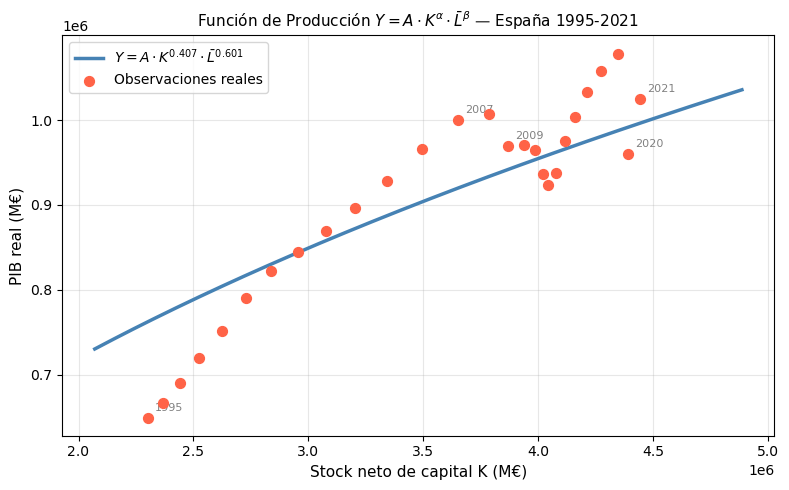

In [266]:
A = np.exp(1.3582)
L_mean = df['L'].mean()
K_range = np.linspace(df['K'].min() * 0.9, df['K'].max() * 1.1, 200)
Y_curve = A * K_range**alpha * L_mean**beta

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_range, Y_curve, color='steelblue', linewidth=2.5, 
        label=r'$Y = A \cdot K^{0.407} \cdot \bar{L}^{0.601}$')
ax.scatter(df['K'], df['GDP'], color='tomato', zorder=5, s=50, label='Observaciones reales')

for year in [1995, 2007, 2009, 2020, 2021]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['K'].values[0], row['GDP'].values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Stock neto de capital K (M€)', fontsize=11)
ax.set_ylabel('PIB real (M€)', fontsize=11)
ax.set_title(r'Función de Producción $Y = A \cdot K^\alpha \cdot \bar{L}^\beta$ — España 1995-2021', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

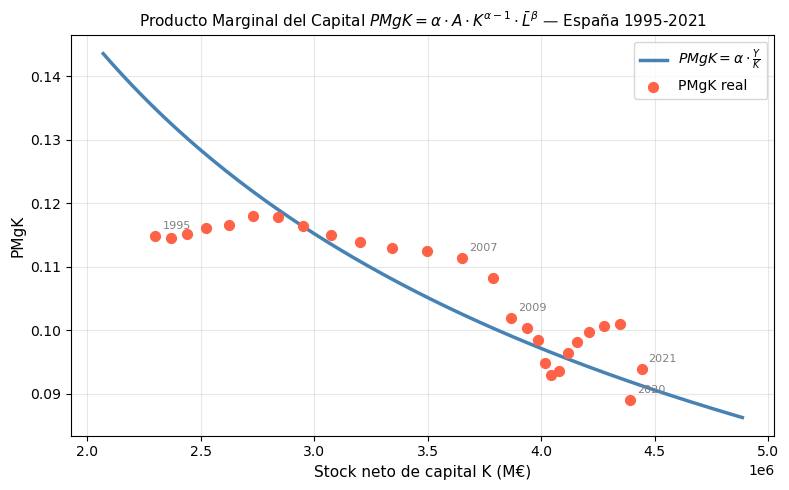

In [267]:
PMgK_curve = alpha * A * K_range**alpha * L_mean**beta / K_range
PMgK_real  = alpha * df['GDP'] / df['K']

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(K_range, PMgK_curve, color='steelblue', linewidth=2.5,
        label=r'$PMgK = \alpha \cdot \frac{Y}{K}$')
ax.scatter(df['K'], PMgK_real, color='tomato', zorder=5, s=50, label='PMgK real')

for year in [1995, 2007, 2009, 2020, 2021]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['K'].values[0], (alpha * row['GDP'] / row['K']).values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Stock neto de capital K (M€)', fontsize=11)
ax.set_ylabel('PMgK', fontsize=11)
ax.set_title(r'Producto Marginal del Capital $PMgK = \alpha \cdot A \cdot K^{\alpha-1} \cdot \bar{L}^\beta$ — España 1995-2021', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

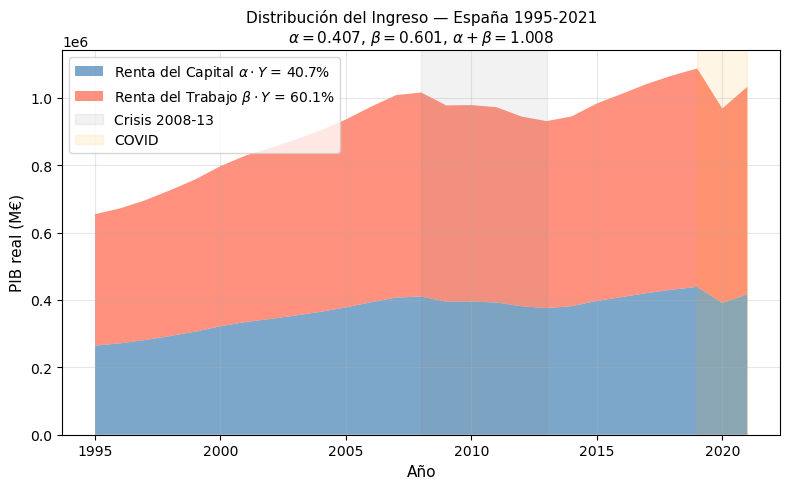

In [268]:
df['renta_K'] = alpha * df['GDP']
df['renta_L'] = beta  * df['GDP']

fig, ax = plt.subplots(figsize=(8, 5))

ax.stackplot(df['year'],
             df['renta_K'],
             df['renta_L'],
             labels=[r'Renta del Capital $\alpha \cdot Y$ = 40.7%',
                     r'Renta del Trabajo $\beta \cdot Y$ = 60.1%'],
             colors=['steelblue', 'tomato'],
             alpha=0.7)

ax.axvspan(2008, 2013, alpha=0.1, color='gray', label='Crisis 2008-13')
ax.axvspan(2019, 2021, alpha=0.1, color='orange', label='COVID')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('PIB real (M€)', fontsize=11)
ax.set_title(r'Distribución del Ingreso — España 1995-2021'
             '\n' r'$\alpha=0.407$, $\beta=0.601$, $\alpha+\beta=1.008$', fontsize=11)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

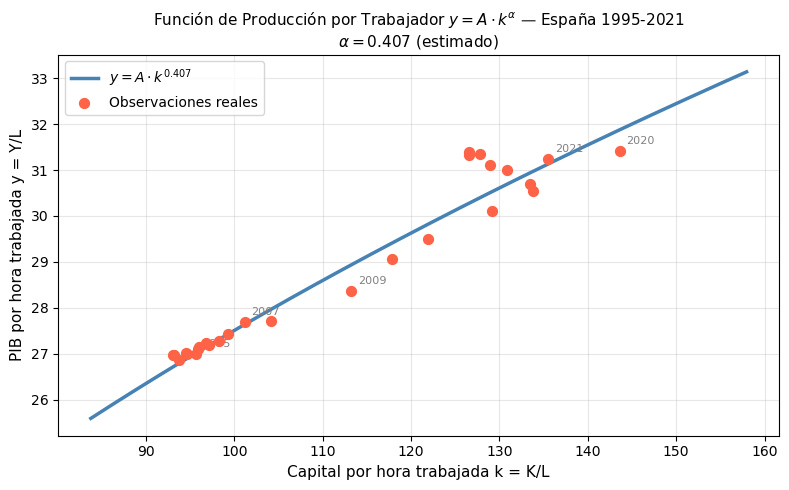

In [269]:
df['y'] = df['GDP'] / df['L']
df['k'] = df['K'] / df['L']

A_pw = df['y'].mean() / (df['k'].mean()**alpha)
k_range = np.linspace(df['k'].min() * 0.9, df['k'].max() * 1.1, 200)
y_curve = A_pw * k_range**alpha

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(k_range, y_curve, color='steelblue', linewidth=2.5,
        label=r'$y = A \cdot k^{0.407}$')
ax.scatter(df['k'], df['y'], color='tomato', zorder=5, s=50, label='Observaciones reales')

for year in [1995, 2007, 2009, 2020, 2021]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['k'].values[0], row['y'].values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Capital por hora trabajada k = K/L', fontsize=11)
ax.set_ylabel('PIB por hora trabajada y = Y/L', fontsize=11)
ax.set_title(r'Función de Producción por Trabajador $y = A \cdot k^\alpha$ — España 1995-2021'
             '\n' r'$\alpha=0.407$ (estimado)', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conclusiones del Proyecto — v2

## Función de Producción Cobb-Douglas — España 1995-2021
### Mankiw Cap. 3 + Wooldridge Cap. 12

---

## 1. Datos
| Variable | Fuente | Descripción |
|---|---|---|
| Y — PIB real | Eurostat `nama_10_gdp` | Volumen encadenado 2005, M€ |
| L — Horas trabajadas | EU KLEMS 2024 | Total horas trabajadas, miles |
| K — Stock de capital | Fundación BBVA-Ivie | Stock neto riqueza, precios constantes 2020, miles € |

**Mejora respecto a v1:** Stock neto de capital real en lugar de FBCF como proxy → α estimado correctamente.

---

## 2. Modelos estimados

### Modelo 1 — Largo plazo (niveles + HAC)
$$\ln(Y) = 1.358 + 0.407\ln(K) + 0.601\ln(L)$$

| Parámetro | Valor | p-valor | Interpretación |
|---|---|---|---|
| A | 3.889 | 0.000 | Nivel de PTF |
| α (capital) | 0.407 | 0.000 | Elasticidad PIB-capital |
| β (trabajo) | 0.601 | 0.000 | Elasticidad PIB-trabajo |
| α + β | 1.008 | — | Rendimientos constantes a escala ✅ |

⚠️ DW=0.713 — autocorrelación presente. Coeficientes insesgados pero usar solo para elasticidades estructurales.

### Modelo 2 — Corto plazo (diferencias + dummies + HAC)
$$\Delta\ln(Y) = 0.010 + 0.003\Delta\ln(K) + 0.762\Delta\ln(L) - 0.001·d_{2009} - 0.037·d_{2020}$$

| Parámetro | Valor | p-valor | Interpretación |
|---|---|---|---|
| PTF | 0.010 | 0.000 | Crecimiento autónomo ~0.99% anual |
| Δln(K) | 0.003 | 0.954 | No significativo a corto plazo |
| Δln(L) | 0.762 | 0.000 | Elasticidad trabajo corto plazo |
| d2009 | -0.001 | 0.558 | Crisis explicada por caída del empleo |
| d2020 | -0.037 | 0.000 | COVID redujo PIB un 3.7% adicional |

✅ DW=2.103, BG p=0.091, normalidad no rechazada.

---

## 3. Conclusiones económicas (Mankiw Cap. 3)

- **Rendimientos constantes a escala** — α+β=1.008, consistente con la teoría neoclásica
- **Participación del capital: 40.7%** del PIB — dentro del rango empírico estándar (30-40%)
- **Participación del trabajo: 60.1%** del PIB — consistente con la literatura para España
- **PTF crece 0.99% anual** — hay progreso tecnológico autónomo en España
- **Capital actúa a largo plazo** — no significativo en diferencias, muy significativo en niveles
- **COVID fue un shock puro** — redujo el PIB un 3.7% adicional al efecto de los factores
- **Crisis 2009 absorbida por el empleo** — no necesita dummy propia

---

## 4. Mejoras respecto a v1

| Aspecto | v1 (FBCF) | v2 (Stock neto) |
|---|---|---|
| α (capital) | -0.489 ❌ | +0.407 ✅ |
| α + β | 1.31 ❌ | 1.008 ✅ |
| DW final | 1.63 ⚠️ | 2.103 ✅ |
| Normalidad | rechazada ❌ | no rechazada ✅ |
| Prais-Winsten | necesario | no necesario ✅ |

---

## 5. Limitaciones

1. **n=27** — muestra pequeña, potencia limitada
2. **No estacionariedad** — test ADF pendiente, posible regresión espuria en niveles
3. **K no significativo a corto plazo** — requiere VECM para separar dinámicas
4. **EU KLEMS solo llega a 2021** — pierde COVID completo y recuperación

## 6. Próximos pasos

- Test ADF y cointegración (Engle-Granger)
- VECM para capturar largo y corto plazo simultáneamente
- Ampliar a panel de países europeos (Wooldridge cap. 13)

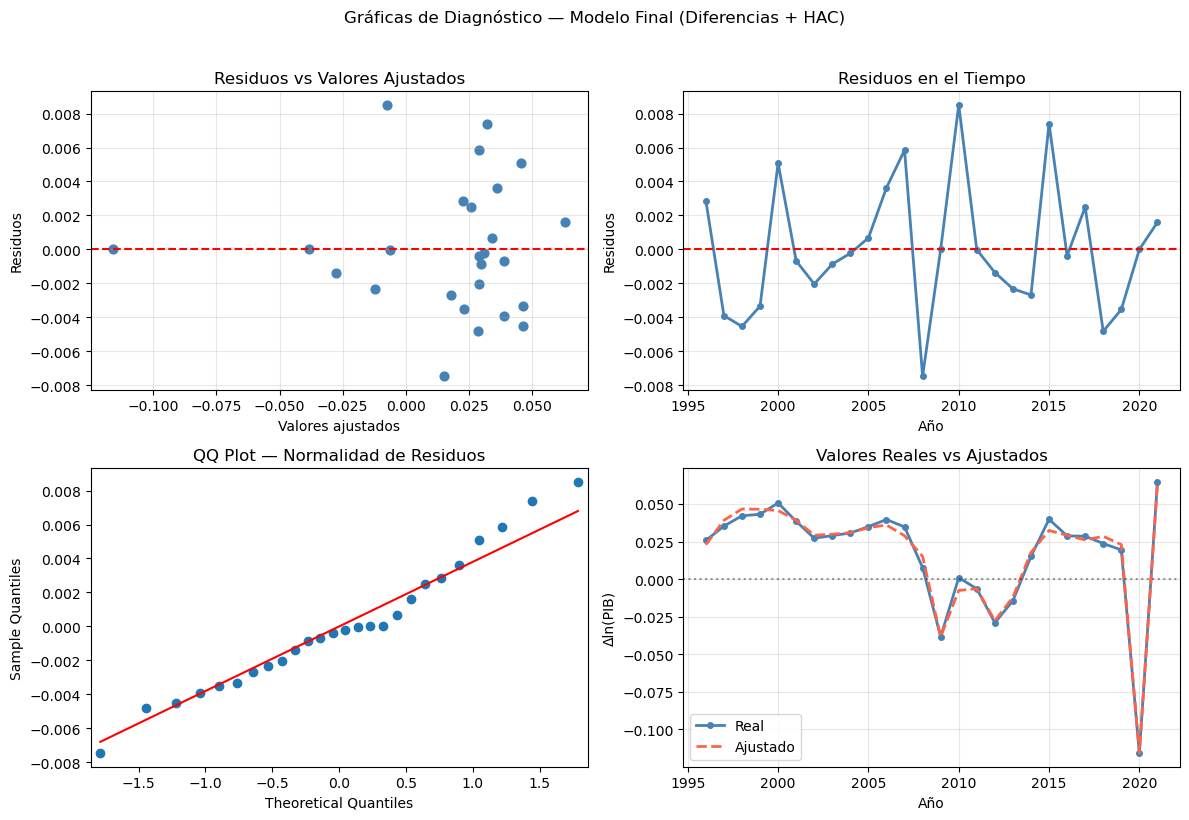

In [270]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Residuos vs valores ajustados
axes[0,0].scatter(modelo_final.fittedvalues, modelo_final.resid, 
                  color='steelblue', s=40)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Valores ajustados')
axes[0,0].set_ylabel('Residuos')
axes[0,0].set_title('Residuos vs Valores Ajustados')
axes[0,0].grid(alpha=0.3)

# 2. Residuos en el tiempo
axes[0,1].plot(df_diff['year'], modelo_final.resid, 
               color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_xlabel('Año')
axes[0,1].set_ylabel('Residuos')
axes[0,1].set_title('Residuos en el Tiempo')
axes[0,1].grid(alpha=0.3)

# 3. QQ Plot
sm.qqplot(modelo_final.resid, line='s', ax=axes[1,0])
axes[1,0].set_title('QQ Plot — Normalidad de Residuos')

# 4. Valores reales vs ajustados
axes[1,1].plot(df_diff['year'], Y_d, color='steelblue', 
               linewidth=2, marker='o', markersize=4, label='Real')
axes[1,1].plot(df_diff['year'], modelo_final.fittedvalues, 
               color='tomato', linewidth=2, linestyle='--', label='Ajustado')
axes[1,1].axhline(0, color='black', linestyle=':', alpha=0.4)
axes[1,1].set_xlabel('Año')
axes[1,1].set_ylabel('Δln(PIB)')
axes[1,1].set_title('Valores Reales vs Ajustados')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

plt.suptitle('Gráficas de Diagnóstico — Modelo Final (Diferencias + HAC)', 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [271]:
df

,year,L,K,GDP,ln_GDP,ln_K,ln_L,dln_GDP,dln_K,dln_L,renta_K,renta_L,y,k
0,1995,24056.454,2300541.925,649404.1,13.383810,14.648655,10.088159,NaN,NaN,NaN,264372.40911,390291.8641,26.995005,95.630966
1,1996,24467.619,2367655.604,666336.7,13.409550,14.677411,10.105106,0.025740,0.028756,0.016947,271265.67057,400468.3567,27.233410,96.766898
2,1997,25423.001,2439775.273,690240.2,13.444795,14.707416,10.143410,0.035245,0.030006,0.038304,280996.78542,414834.3602,27.150225,95.967241
3,1998,26676.910,2525004.124,719934.2,13.486915,14.741753,10.191554,0.042120,0.034337,0.048144,293085.21282,432680.4542,26.987166,94.651297
4,1999,27985.967,2622690.455,751675.1,13.530059,14.779711,10.239458,0.043144,0.037958,0.047905,306006.93321,451756.7351,26.859000,93.714484
5,2000,29326.206,2729495.346,790767.0,13.580759,14.819627,10.286237,0.050699,0.039916,0.046778,321921.24570,475250.9670,26.964518,93.073592
6,2001,30469.190,2839281.805,821757.9,13.619201,14.859062,10.324471,0.038442,0.039434,0.038234,334537.64109,493876.4979,26.970126,93.185339
7,2002,31248.173,2952652.054,844401.1,13.646383,14.898214,10.349716,0.027182,0.039153,0.025245,343755.68781,507485.0611,27.022415,94.490390
8,2003,32072.817,3075570.314,869220.5,13.675352,14.939001,10.375764,0.028969,0.040787,0.026048,353859.66555,522401.5205,27.101470,95.893364
9,2004,32965.055,3203657.387,896292.6,13.706022,14.979804,10.403203,0.030670,0.040803,0.027439,364880.71746,538671.8526,27.189174,97.183438


In [272]:
df['PTF'] = df['GDP'] / (df['K']**alpha * df['L']**beta)

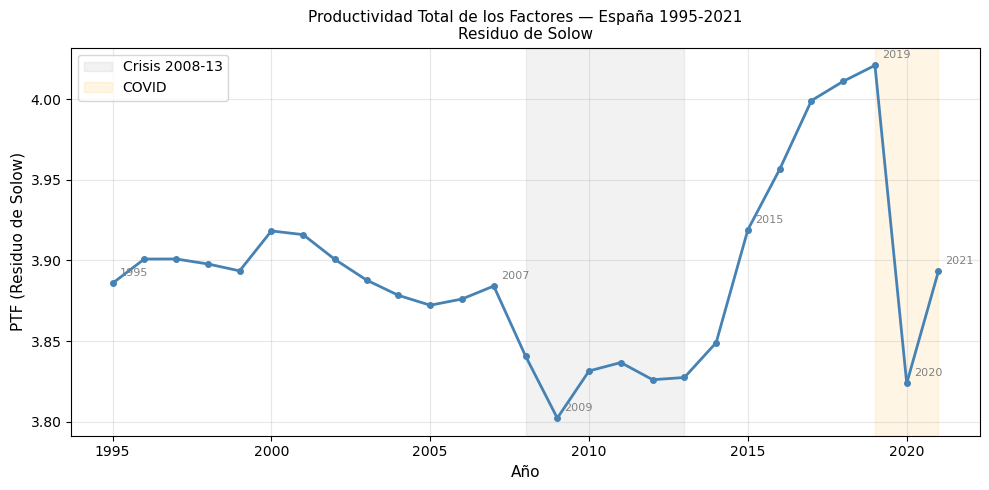

In [273]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['year'], df['PTF'], color='steelblue', linewidth=2, marker='o', markersize=4)
ax.axvspan(2008, 2013, alpha=0.1, color='gray', label='Crisis 2008-13')
ax.axvspan(2019, 2021, alpha=0.1, color='orange', label='COVID')

for year in [1995, 2007, 2009, 2015, 2019, 2020, 2021]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['year'].values[0], row['PTF'].values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('PTF (Residuo de Solow)', fontsize=11)
ax.set_title('Productividad Total de los Factores — España 1995-2021\nResiduo de Solow', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<positron-console-cell-274>:23: SyntaxWarning: invalid escape sequence '\c'


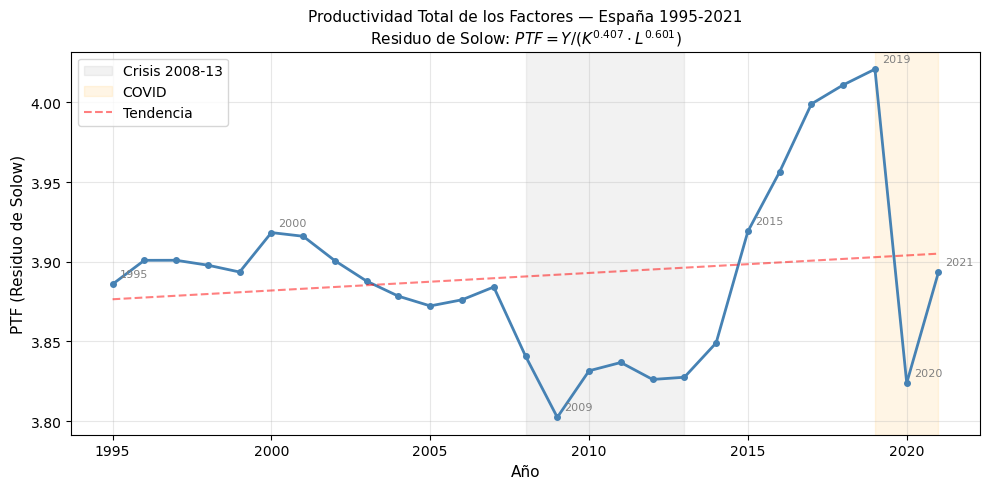

In [274]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df['year'], df['PTF'], color='steelblue', linewidth=2, marker='o', markersize=4)
ax.axvspan(2008, 2013, alpha=0.1, color='gray', label='Crisis 2008-13')
ax.axvspan(2019, 2021, alpha=0.1, color='orange', label='COVID')

# Línea de tendencia
z = np.polyfit(df['year'], df['PTF'], 1)
p = np.poly1d(z)
ax.plot(df['year'], p(df['year']), color='red', linestyle='--', alpha=0.5, label='Tendencia')

for year in [1995, 2000, 2009, 2015, 2019, 2020, 2021]:
    row = df[df['year'] == year]
    if len(row) > 0:
        ax.annotate(str(year),
                    xy=(row['year'].values[0], row['PTF'].values[0]),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=8, color='gray')

ax.set_xlabel('Año', fontsize=11)
ax.set_ylabel('PTF (Residuo de Solow)', fontsize=11)
ax.set_title('Productividad Total de los Factores — España 1995-2021\n'
             'Residuo de Solow: $PTF = Y / (K^{0.407} \cdot L^{0.601})$', fontsize=11)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()